In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Generated_Wafer_Database.xlsx")

In [3]:
print(df.head())

  Lot_Id Wafer_Id  Process_Step  Particle_Count  Oxide_Thickness_nm  \
0    L01     W001  RCA Cleaning               5                5.00   
1    L01     W002  RCA Cleaning               5                5.03   
2    L01     W003  RCA Cleaning               5                4.94   
3    L01     W004  RCA Cleaning               3                4.96   
4    L01     W005  RCA Cleaning              10                5.01   

   Overlay_Error_nm  Implant_Dose_Error_%  Metal_Voids  Total_Dies  Good_Dies  \
0              2.32                  0.53            0        1200       1186   
1              1.71                  0.22            0        1200       1186   
2              1.14                  0.22            1        1200       1177   
3              2.73                  0.27            0        1200       1184   
4              2.06                  0.22            0        1200       1185   

   Bad_Dies Major_Defect Process_Status  Yield_%     Dominant_Root_Cause  
0        14

In [5]:
print(df.shape)

(250, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Lot_Id                250 non-null    object 
 1   Wafer_Id              250 non-null    object 
 2   Process_Step          250 non-null    object 
 3   Particle_Count        250 non-null    int64  
 4   Oxide_Thickness_nm    250 non-null    float64
 5   Overlay_Error_nm      250 non-null    float64
 6   Implant_Dose_Error_%  250 non-null    float64
 7   Metal_Voids           250 non-null    int64  
 8   Total_Dies            250 non-null    int64  
 9   Good_Dies             250 non-null    int64  
 10  Bad_Dies              250 non-null    int64  
 11  Major_Defect          250 non-null    object 
 12  Process_Status        250 non-null    object 
 13  Yield_%               250 non-null    float64
 14  Dominant_Root_Cause   250 non-null    object 
dtypes: float64(4), int64(5)

In [7]:
df.describe()

,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Yield_%
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000
mean,7.504000,5.032040,2.822960,0.626800,1.932000,1200.0,1165.092000,34.908000,97.092480
std,2.942894,0.040393,0.793761,0.278541,1.760618,0.0,16.588437,16.588437,1.383378
min,0.000000,4.920000,1.140000,0.090000,0.000000,1200.0,1116.000000,7.000000,93.000000
25%,5.000000,5.000000,2.217500,0.430000,1.000000,1200.0,1155.000000,23.000000,96.280000
50%,7.000000,5.030000,2.740000,0.585000,1.500000,1200.0,1170.000000,30.000000,97.470000
75%,10.000000,5.060000,3.352500,0.830000,3.000000,1200.0,1177.000000,45.000000,98.107500
max,15.000000,5.130000,5.080000,1.410000,10.000000,1200.0,1193.000000,84.000000,99.390000


In [8]:
df.isnull().sum()

Lot_Id                  0
Wafer_Id                0
Process_Step            0
Particle_Count          0
Oxide_Thickness_nm      0
Overlay_Error_nm        0
Implant_Dose_Error_%    0
Metal_Voids             0
Total_Dies              0
Good_Dies               0
Bad_Dies                0
Major_Defect            0
Process_Status          0
Yield_%                 0
Dominant_Root_Cause     0
dtype: int64

In [9]:
print("Average Yield =", round(df["Yield_%"].mean(),2))

Average Yield = 97.09


In [10]:
df.nlargest(5,"Yield_%")

,Lot_Id,Wafer_Id,Process_Step,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Major_Defect,Process_Status,Yield_%,Dominant_Root_Cause
232,L10,W233,RCA Cleaning,3,5.00,1.84,0.12,0,1200,1193,7,Particle,Pass,99.39,Particle Contamination
18,L01,W019,Photolithography,0,5.01,1.80,0.26,0,1200,1192,8,Overlay Error,Pass,99.35,Photolithography Overlay Drift
31,L02,W032,RCA Cleaning,4,5.01,1.52,0.28,0,1200,1190,10,Particle,Pass,99.14,Particle Contamination
235,L10,W236,RCA Cleaning,3,5.02,1.49,0.22,0,1200,1190,10,Particle,Pass,99.14,Particle Contamination
244,L10,W245,Photolithography,2,4.99,2.60,0.21,0,1200,1189,11,Overlay Error,Pass,99.12,Photolithography Overlay Drift


In [11]:
df.nsmallest(5,"Yield_%")

,Lot_Id,Wafer_Id,Process_Step,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Major_Defect,Process_Status,Yield_%,Dominant_Root_Cause
221,L09,W222,Metallization,13,5.10,4.43,1.01,10,1200,1116,84,Metal Void,Fail,93.00,Metal Void Formation
213,L09,W214,Metallization,15,5.05,2.85,1.03,8,1200,1118,82,Metal Void,Fail,93.16,Metal Void Formation
222,L09,W223,Metallization,13,5.08,3.95,1.09,7,1200,1118,82,Metal Void,Fail,93.18,Metal Void Formation
209,L09,W210,Metallization,11,5.07,3.81,1.13,7,1200,1121,79,Metal Void,Fail,93.41,Metal Void Formation
156,L07,W157,Metallization,7,5.09,3.16,0.97,7,1200,1124,76,Metal Void,Fail,93.66,Metal Void Formation


In [12]:
lot_yield = df.groupby("Lot_Id")["Yield_%"].mean()

print(lot_yield)

Lot_Id
L01    98.4672
L02    98.2552
L03    97.7532
L04    97.5460
L05    96.8956
L06    97.0232
L07    96.1712
L08    95.7932
L09    94.7480
L10    98.2720
Name: Yield_%, dtype: float64


In [13]:
df["Major_Defect"].value_counts()

Particle         215
Metal Void        29
Overlay Error      3
Implant Error      3
Name: Major_Defect, dtype: int64

In [14]:
df["Process_Status"].value_counts()

Warning    151
Pass        76
Fail        23
Name: Process_Status, dtype: int64

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Generated_Wafer_Database.xlsx")

In [16]:
df.head()

,Lot_Id,Wafer_Id,Process_Step,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Major_Defect,Process_Status,Yield_%,Dominant_Root_Cause
0,L01,W001,RCA Cleaning,5,5.00,2.32,0.53,0,1200,1186,14,Particle,Pass,98.86,Particle Contamination
1,L01,W002,RCA Cleaning,5,5.03,1.71,0.22,0,1200,1186,14,Particle,Pass,98.86,Particle Contamination
2,L01,W003,RCA Cleaning,5,4.94,1.14,0.22,1,1200,1177,23,Particle,Pass,98.10,Particle Contamination
3,L01,W004,RCA Cleaning,3,4.96,2.73,0.27,0,1200,1184,16,Particle,Pass,98.63,Particle Contamination
4,L01,W005,RCA Cleaning,10,5.01,2.06,0.22,0,1200,1185,15,Particle,Pass,98.73,Particle Contamination


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Lot_Id                250 non-null    object 
 1   Wafer_Id              250 non-null    object 
 2   Process_Step          250 non-null    object 
 3   Particle_Count        250 non-null    int64  
 4   Oxide_Thickness_nm    250 non-null    float64
 5   Overlay_Error_nm      250 non-null    float64
 6   Implant_Dose_Error_%  250 non-null    float64
 7   Metal_Voids           250 non-null    int64  
 8   Total_Dies            250 non-null    int64  
 9   Good_Dies             250 non-null    int64  
 10  Bad_Dies              250 non-null    int64  
 11  Major_Defect          250 non-null    object 
 12  Process_Status        250 non-null    object 
 13  Yield_%               250 non-null    float64
 14  Dominant_Root_Cause   250 non-null    object 
dtypes: float64(4), int64(5)

In [18]:
df.describe()

,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Yield_%
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000
mean,7.504000,5.032040,2.822960,0.626800,1.932000,1200.0,1165.092000,34.908000,97.092480
std,2.942894,0.040393,0.793761,0.278541,1.760618,0.0,16.588437,16.588437,1.383378
min,0.000000,4.920000,1.140000,0.090000,0.000000,1200.0,1116.000000,7.000000,93.000000
25%,5.000000,5.000000,2.217500,0.430000,1.000000,1200.0,1155.000000,23.000000,96.280000
50%,7.000000,5.030000,2.740000,0.585000,1.500000,1200.0,1170.000000,30.000000,97.470000
75%,10.000000,5.060000,3.352500,0.830000,3.000000,1200.0,1177.000000,45.000000,98.107500
max,15.000000,5.130000,5.080000,1.410000,10.000000,1200.0,1193.000000,84.000000,99.390000


In [19]:
df.isnull().sum()

Lot_Id                  0
Wafer_Id                0
Process_Step            0
Particle_Count          0
Oxide_Thickness_nm      0
Overlay_Error_nm        0
Implant_Dose_Error_%    0
Metal_Voids             0
Total_Dies              0
Good_Dies               0
Bad_Dies                0
Major_Defect            0
Process_Status          0
Yield_%                 0
Dominant_Root_Cause     0
dtype: int64

In [20]:
lot_yield = df.groupby("Lot_Id")["Yield_%"].mean()

lot_yield

Lot_Id
L01    98.4672
L02    98.2552
L03    97.7532
L04    97.5460
L05    96.8956
L06    97.0232
L07    96.1712
L08    95.7932
L09    94.7480
L10    98.2720
Name: Yield_%, dtype: float64

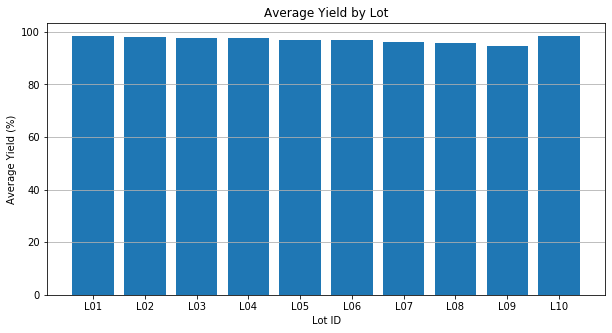

In [21]:
plt.figure(figsize=(10,5))

plt.bar(lot_yield.index, lot_yield.values)

plt.xlabel("Lot ID")
plt.ylabel("Average Yield (%)")
plt.title("Average Yield by Lot")

plt.grid(axis="y")

plt.show()

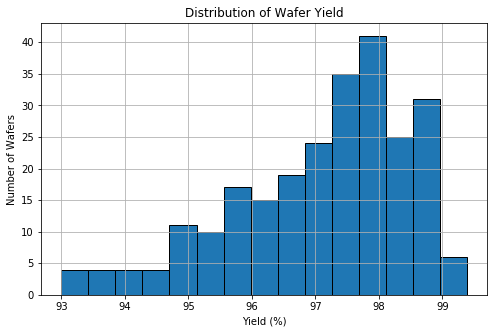

In [22]:
#Analysis 1: Yield Distribution
plt.figure(figsize=(8,5))

plt.hist(df["Yield_%"], bins=15, edgecolor="black")

plt.xlabel("Yield (%)")
plt.ylabel("Number of Wafers")
plt.title("Distribution of Wafer Yield")

plt.grid(True)

plt.show()

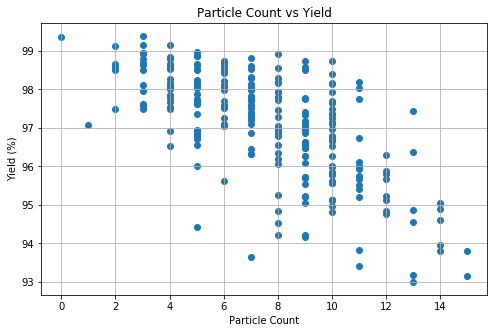

In [23]:
#Analysis 2: Particle Count vs Yield
plt.figure(figsize=(8,5))

plt.scatter(df["Particle_Count"], df["Yield_%"])

plt.xlabel("Particle Count")
plt.ylabel("Yield (%)")
plt.title("Particle Count vs Yield")

plt.grid(True)

plt.show()

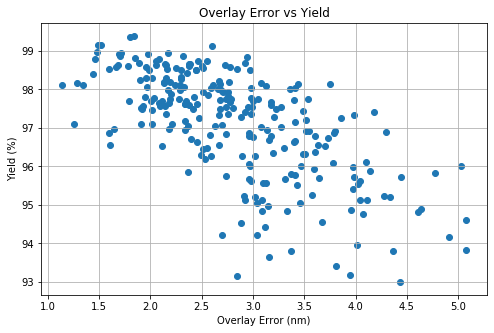

In [24]:
#Analysis 3: Overlay Error vs Yield
plt.figure(figsize=(8,5))

plt.scatter(df["Overlay_Error_nm"], df["Yield_%"])

plt.xlabel("Overlay Error (nm)")
plt.ylabel("Yield (%)")
plt.title("Overlay Error vs Yield")

plt.grid(True)

plt.show()

In [25]:
#Analysis 4: Defect Frequency (Pareto Preparation)
defect_count = df["Major_Defect"].value_counts()

print(defect_count)

Particle         215
Metal Void        29
Overlay Error      3
Implant Error      3
Name: Major_Defect, dtype: int64


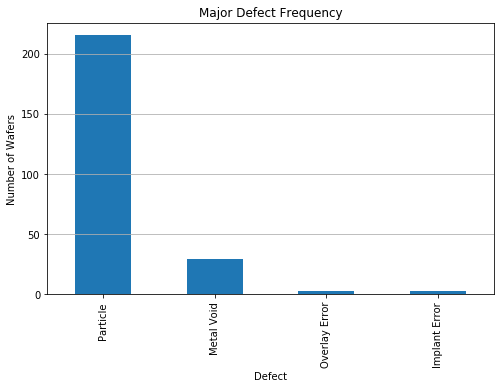

In [26]:
plt.figure(figsize=(8,5))

defect_count.plot(kind="bar")

plt.xlabel("Defect")

plt.ylabel("Number of Wafers")

plt.title("Major Defect Frequency")

plt.grid(axis="y")

plt.show()

In [27]:
#Analysis 5: Correlation Matrix
corr = df[
[
"Particle_Count",
"Oxide_Thickness_nm",
"Overlay_Error_nm",
"Implant_Dose_Error_%",
"Metal_Voids",
"Yield_%"
]
].corr()

print(corr)

                      Particle_Count  Oxide_Thickness_nm  Overlay_Error_nm  \
Particle_Count              1.000000            0.459238          0.561017   
Oxide_Thickness_nm          0.459238            1.000000          0.460488   
Overlay_Error_nm            0.561017            0.460488          1.000000   
Implant_Dose_Error_%        0.601556            0.545541          0.662168   
Metal_Voids                 0.448451            0.382015          0.443791   
Yield_%                    -0.672747           -0.652757         -0.662319   

                      Implant_Dose_Error_%  Metal_Voids   Yield_%  
Particle_Count                    0.601556     0.448451 -0.672747  
Oxide_Thickness_nm                0.545541     0.382015 -0.652757  
Overlay_Error_nm                  0.662168     0.443791 -0.662319  
Implant_Dose_Error_%              1.000000     0.457173 -0.726521  
Metal_Voids                       0.457173     1.000000 -0.884698  
Yield_%                          -0.726521   

In [28]:
#Analysis 6: Worst Wafers
worst = df.nsmallest(10, "Yield_%")

worst

,Lot_Id,Wafer_Id,Process_Step,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Major_Defect,Process_Status,Yield_%,Dominant_Root_Cause
221,L09,W222,Metallization,13,5.10,4.43,1.01,10,1200,1116,84,Metal Void,Fail,93.00,Metal Void Formation
213,L09,W214,Metallization,15,5.05,2.85,1.03,8,1200,1118,82,Metal Void,Fail,93.16,Metal Void Formation
222,L09,W223,Metallization,13,5.08,3.95,1.09,7,1200,1118,82,Metal Void,Fail,93.18,Metal Void Formation
209,L09,W210,Metallization,11,5.07,3.81,1.13,7,1200,1121,79,Metal Void,Fail,93.41,Metal Void Formation
156,L07,W157,Metallization,7,5.09,3.16,0.97,7,1200,1124,76,Metal Void,Fail,93.66,Metal Void Formation
218,L09,W219,RCA Cleaning,14,5.12,3.37,1.02,5,1200,1126,74,Particle,Fail,93.80,Particle Contamination
219,L09,W220,RCA Cleaning,15,5.13,4.37,1.19,4,1200,1126,74,Particle,Fail,93.80,Particle Contamination
202,L09,W203,Metallization,11,5.03,5.08,0.93,7,1200,1126,74,Metal Void,Fail,93.82,Metal Void Formation
204,L09,W205,RCA Cleaning,14,5.05,4.01,1.10,6,1200,1128,72,Particle,Fail,93.96,Particle Contamination
223,L09,W224,Metallization,9,5.08,4.91,1.19,5,1200,1130,70,Metal Void,Fail,94.16,Metal Void Formation


In [30]:
#Now the database generation & Exploratory Data Analysis (EDA) both are done
#Now we need to do Statistical Process Control (SPC)
#Then the Root Cause Analysis
#Engineering Recommendations

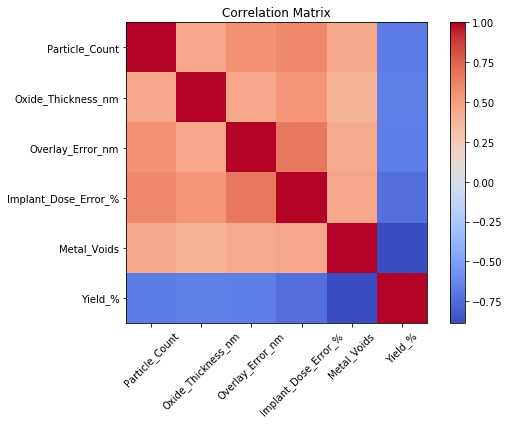

                      Particle_Count  Oxide_Thickness_nm  Overlay_Error_nm  \
Particle_Count              1.000000            0.459238          0.561017   
Oxide_Thickness_nm          0.459238            1.000000          0.460488   
Overlay_Error_nm            0.561017            0.460488          1.000000   
Implant_Dose_Error_%        0.601556            0.545541          0.662168   
Metal_Voids                 0.448451            0.382015          0.443791   
Yield_%                    -0.672747           -0.652757         -0.662319   

                      Implant_Dose_Error_%  Metal_Voids   Yield_%  
Particle_Count                    0.601556     0.448451 -0.672747  
Oxide_Thickness_nm                0.545541     0.382015 -0.652757  
Overlay_Error_nm                  0.662168     0.443791 -0.662319  
Implant_Dose_Error_%              1.000000     0.457173 -0.726521  
Metal_Voids                       0.457173     1.000000 -0.884698  
Yield_%                          -0.726521   

In [31]:
#Creating a Correlation Heatmap
import matplotlib.pyplot as plt

corr = df[
[
    "Particle_Count",
    "Oxide_Thickness_nm",
    "Overlay_Error_nm",
    "Implant_Dose_Error_%",
    "Metal_Voids",
    "Yield_%"
]
].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

print(corr)

In [32]:
#Statistical Process Control (SPC)
yield_mean = df["Yield_%"].mean()

yield_std = df["Yield_%"].std()

UCL = yield_mean + 3 * yield_std
LCL = yield_mean - 3 * yield_std

print("Mean =", yield_mean)
print("Std Dev =", yield_std)
print("UCL =", UCL)
print("LCL =", LCL)

Mean = 97.09247999999995
Std Dev = 1.3833781805281757
UCL = 101.24261454158447
LCL = 92.94234545841543


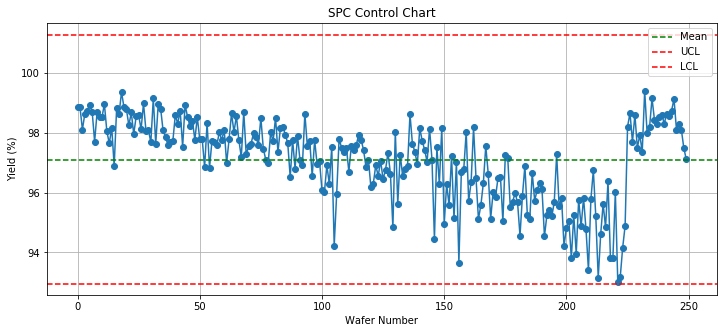

In [33]:
#control Chart
plt.figure(figsize=(12,5))

plt.plot(df["Yield_%"], marker='o')

plt.axhline(yield_mean, color='green', linestyle='--', label='Mean')
plt.axhline(UCL, color='red', linestyle='--', label='UCL')
plt.axhline(LCL, color='red', linestyle='--', label='LCL')

plt.xlabel("Wafer Number")
plt.ylabel("Yield (%)")
plt.title("SPC Control Chart")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
#Root Cause Analysis
worst_lot = df.groupby("Lot_Id")["Yield_%"].mean().idxmin()

print(worst_lot)

L09


In [35]:
df[df["Lot_Id"] == worst_lot]

,Lot_Id,Wafer_Id,Process_Step,Particle_Count,Oxide_Thickness_nm,Overlay_Error_nm,Implant_Dose_Error_%,Metal_Voids,Total_Dies,Good_Dies,Bad_Dies,Major_Defect,Process_Status,Yield_%,Dominant_Root_Cause
200,L09,W201,RCA Cleaning,10,5.07,4.61,1.12,4,1200,1138,62,Particle,Fail,94.83,Particle Contamination
201,L09,W202,RCA Cleaning,14,5.10,3.46,0.97,3,1200,1141,59,Particle,Warning,95.06,Particle Contamination
202,L09,W203,Metallization,11,5.03,5.08,0.93,7,1200,1126,74,Metal Void,Fail,93.82,Metal Void Formation
203,L09,W204,RCA Cleaning,12,5.11,4.28,1.19,2,1200,1143,57,Particle,Warning,95.24,Particle Contamination
204,L09,W205,RCA Cleaning,14,5.05,4.01,1.10,6,1200,1128,72,Particle,Fail,93.96,Particle Contamination
205,L09,W206,RCA Cleaning,11,5.10,2.74,1.11,2,1200,1149,51,Particle,Warning,95.76,Particle Contamination
206,L09,W207,RCA Cleaning,13,5.10,3.96,1.17,3,1200,1138,62,Particle,Fail,94.87,Particle Contamination
207,L09,W208,RCA Cleaning,10,5.10,4.77,1.28,1,1200,1150,50,Particle,Warning,95.82,Particle Contamination
208,L09,W209,RCA Cleaning,12,5.12,4.07,1.05,3,1200,1137,63,Particle,Fail,94.77,Particle Contamination
209,L09,W210,Metallization,11,5.07,3.81,1.13,7,1200,1121,79,Metal Void,Fail,93.41,Metal Void Formation


Root Cause Analysis :

The analysis of the simulated semiconductor manufacturing dataset was performed to identify the primary factors responsible for wafer yield degradation. The results obtained from the exploratory data analysis, yield distribution, defect frequency analysis, correlation matrix, scatter plots, and Statistical Process Control (SPC) charts indicate that process variations have a direct impact on manufacturing yield. Among the monitored process parameters, particle contamination exhibited the strongest negative relationship with wafer yield. Wafers containing higher particle counts consistently produced lower yields due to an increased probability of defects occurring during critical fabrication stages such as oxidation, lithography, and metallization. In addition to contamination, overlay error was identified as another significant contributor to yield loss. Larger lithography alignment errors increase the likelihood of pattern misalignment, resulting in defective devices and reduced die functionality. Implant dose variation and metal void formation also contributed to yield degradation, although their impact was comparatively lower than that of particle contamination and overlay error. Lot-wise yield analysis further revealed that certain production lots consistently demonstrated lower average yields, suggesting the presence of systematic process drift rather than isolated wafer failures. The SPC control chart was used to evaluate overall process stability and to identify wafers operating outside the expected process limits. Overall, the investigation indicates that contamination control, lithography alignment accuracy, and continuous monitoring of critical process parameters are the most important areas requiring attention to improve manufacturing yield.

Engineering Recommendations :

Based on the results of the yield analysis and root cause investigation, several process improvements are recommended to enhance semiconductor manufacturing yield. Since particle contamination was identified as the dominant yield-limiting factor, improving cleanroom contamination control should be considered the highest priority. This can be achieved through regular maintenance of HEPA filtration systems, stricter wafer handling procedures, enhanced chamber cleaning schedules, and continuous monitoring of airborne particle concentrations. To reduce overlay-related defects, periodic calibration of lithography equipment, accurate alignment mark inspection, and routine maintenance of stage positioning systems should be implemented to improve pattern alignment accuracy. Implant dose variation can be minimized by regularly calibrating ion implantation equipment and incorporating Statistical Process Control (SPC) monitoring to detect deviations before they affect production. Metal void defects may be reduced by optimizing sputtering and metallization process parameters, maintaining stable chamber vacuum conditions, and strengthening post-deposition inspection procedures. Continuous monitoring of key process indicators through SPC charts should be integrated into the manufacturing workflow to detect abnormal process behavior at an early stage and prevent large-scale yield losses. Finally, periodic review of production data, defect trends, and process capability metrics should be performed to support data-driven process optimization and continuous improvement of semiconductor manufacturing operations.

Conclusion :

This project demonstrates the application of data analytics and statistical process control techniques to evaluate semiconductor manufacturing yield using a simulated wafer fabrication dataset. A database consisting of 250 wafers across 10 production lots was generated and analyzed using Python, Pandas, NumPy, and Matplotlib. Statistical analysis identified particle contamination and lithography overlay error as the primary contributors to yield degradation. Based on these findings, engineering recommendations were proposed to improve process stability, reduce defect occurrence, and enhance overall wafer yield. The methodology followed in this project reflects the typical workflow of a semiconductor Yield Engineer, including data generation, defect analysis, process monitoring, root cause investigation, and continuous process improvement.